In [0]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import mlflow
import mlflow.sklearn

from datetime import datetime

print("Libraries loaded successfully")

Libraries loaded successfully


In [0]:
!pip install xgboost -q
%pip install lightgbm

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


{"ts": "2026-09-02 11:54:10.856", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMTY2MzA0ODg0NjM5MTI5ORABIAEyJDAxYTA2MWY3LTkzNDYtNzkyNy04NGViLWU0ODUwNDc3ODE1NTokYThiMDFkNTctNDVmZS0zNDljLWFjNjgtZGRjNjI5NjMxZDFhSgsIupzg1AYQgLPkVlABWAFgAWjv6vvIjsWjDQ==.", "context": {}}
{"ts": "2026-09-02 11:54:10.856", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMTY2MzA0ODg0NjM5MTI5ORABIAEyJDAxYTA2MWY3LTkzNDYtNzkyNy04NGViLWU0ODUwNDc3ODE1NTokYThiMDFkNTctNDVmZS0zNDljLWFjNjgtZGRjNjI5NjMxZDFhSgsIupzg1AYQgLPkVlABWAFgAWjv6vvIjsWjDQ==.", "context": {}}
{"ts": "2026-09-02 11:54:10.856", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMTY2MzA0ODg0NjM5MTI5ORABIAEyJDAxYTA2MWY3LTkzNDYtNzkyNy04NGViLWU0ODUwNDc3ODE1NTokYThiMDFkNTctNDVmZS0zNDljLWFjNjgtZGRjNjI5NjMxZDFh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.1 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
DATA_PATH = "demand_forecasting.csv"

df = pd.read_csv(DATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Rows: 76000
Columns: 16


Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [0]:
display(
    pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isnull().sum().values,
        "unique_values": [
            df[c].nunique() for c in df.columns
        ]
    })
)

column,dtype,missing_values,unique_values
Date,object,0,760
Store ID,object,0,5
Product ID,object,0,20
Category,object,0,5
Region,object,0,4
Inventory Level,int64,0,1426
Units Sold,int64,0,330
Units Ordered,int64,0,996
Price,float64,0,15396
Discount,int64,0,6


In [0]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

display(df.head())

Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
2022-01-01T00:00:00.000Z,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
2022-01-02T00:00:00.000Z,S001,P0001,Electronics,North,93,71,0,65.63,5,Snowy,0,73.66,Winter,0,84
2022-01-03T00:00:00.000Z,S001,P0001,Electronics,North,274,142,229,68.55,15,Snowy,1,80.73,Winter,0,132
2022-01-04T00:00:00.000Z,S001,P0001,Electronics,North,132,42,0,61.66,10,Snowy,0,54.88,Winter,0,67
2022-01-05T00:00:00.000Z,S001,P0001,Electronics,North,319,129,0,59.56,25,Snowy,1,57.34,Winter,0,110


In [0]:
print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

print(
    "Number of days:",
    (df["Date"].max() - df["Date"].min()).days + 1
)

Minimum date: 2022-01-01 00:00:00
Maximum date: 2024-01-30 00:00:00
Number of days: 760


In [0]:
print("Stores:", df["Store ID"].nunique())
print("Products:", df["Product ID"].nunique())
print("Categories:", df["Category"].nunique())
print("Regions:", df["Region"].nunique())

Stores: 5
Products: 20
Categories: 5
Regions: 4


In [0]:
display(
    df.groupby(["Store ID", "Product ID"])
      .size()
      .describe()
)

count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
dtype: float64

In [0]:
display(df["Demand"].describe())

count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64

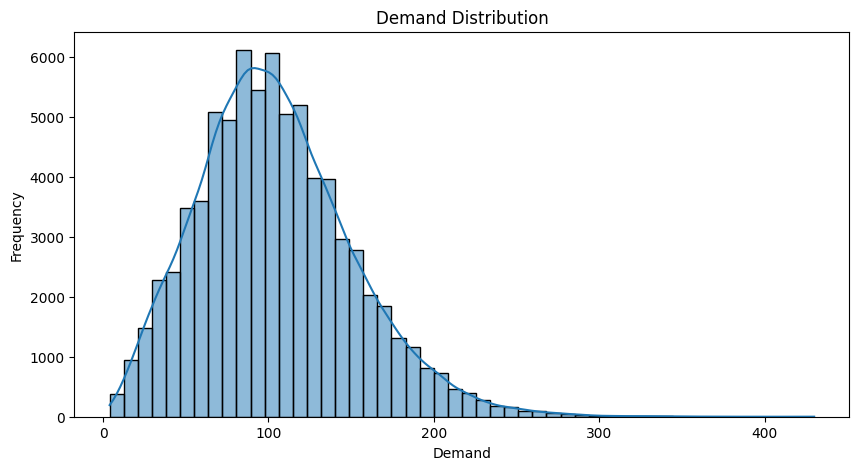

In [0]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Demand"],
    bins=50,
    kde=True
)

plt.title("Demand Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.show()

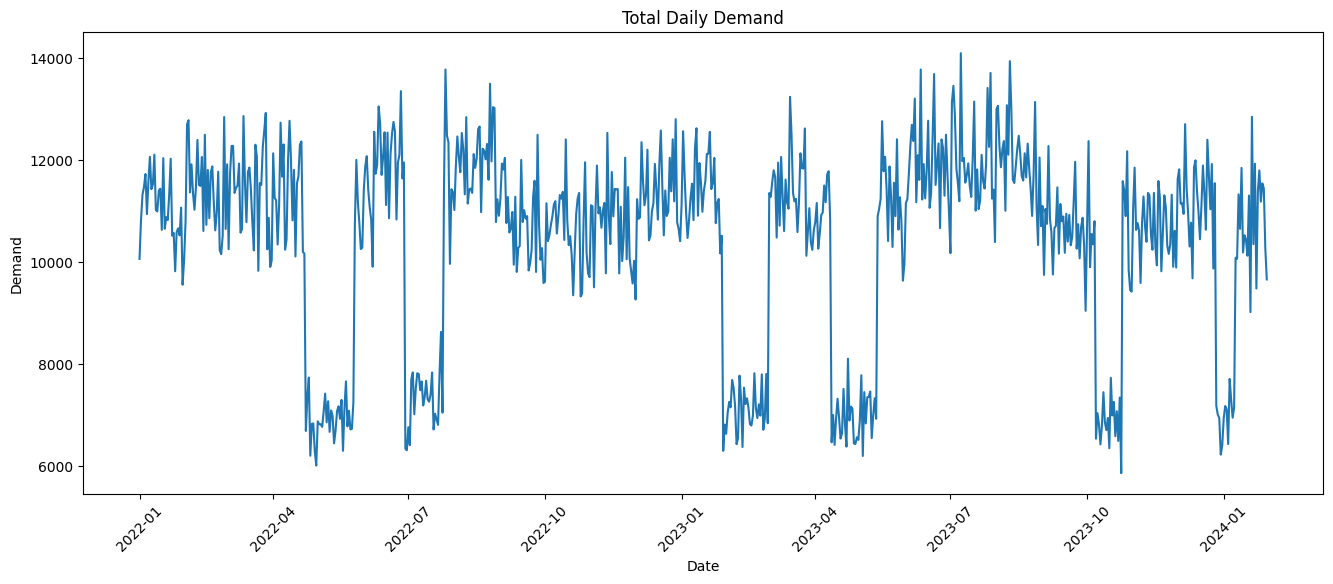

In [0]:
daily_demand = (
    df.groupby("Date")["Demand"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Demand"]
)

plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.xticks(rotation=45)

plt.show()

In [0]:
display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_values")
)

missing_values
0
0
0
0
0
0
0
0
0
0


In [0]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [0]:
zero_demand_count = (df["Demand"] == 0).sum()

print("Rows with zero demand:", zero_demand_count)

print("Percentage of zero demand:",round(zero_demand_count / len(df) * 100,2),"%")


Rows with zero demand: 0
Percentage of zero demand: 0.0 %


In [0]:
numeric_columns = df.select_dtypes(include=np.number).columns

display(df[numeric_columns].corr())


Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
1.0,0.23459035858121532,-0.0346976555291466,-0.03667328515228306,-6.783217335447963E-4,-0.0060822441497047726,-0.03475360613120642,-0.09754973957578558,0.1266180753549882
0.23459035858121532,1.0,0.4339425158265425,-0.014506275744616905,0.18352343298248255,0.22706231658347145,-0.013988988569070424,-0.3178550395968998,0.8334214303439826
-0.0346976555291466,0.4339425158265425,1.0,0.04497952655626822,0.17297207627282213,0.214742537563452,0.04523492776901224,-0.10054566404331244,0.5119626250855679
-0.03667328515228306,-0.014506275744616905,0.04497952655626822,1.0,-0.09413649585858747,-0.04318991993887278,0.9766482862686766,-0.08965796419267197,-0.02346082195720549
-6.783217335447963E-4,0.18352343298248255,0.17297207627282213,-0.09413649585858747,1.0,0.7840389064554016,-0.09206640378600665,-0.00388537907050438,0.22472264702914369
-0.0060822441497047726,0.22706231658347145,0.214742537563452,-0.04318991993887278,0.7840389064554016,1.0,-0.04138460665320768,7.00140042014001E-4,0.28253735954038234
-0.03475360613120642,-0.013988988569070424,0.04523492776901224,0.9766482862686766,-0.09206640378600665,-0.04138460665320768,1.0,-0.08946614092834985,-0.023036445032016316
-0.09754973957578558,-0.3178550395968998,-0.10054566404331244,-0.08965796419267197,-0.00388537907050438,7.00140042014001E-4,-0.08946614092834985,1.0,-0.36366135982713915
0.1266180753549882,0.8334214303439826,0.5119626250855679,-0.02346082195720549,0.22472264702914369,0.28253735954038234,-0.023036445032016316,-0.36366135982713915,1.0


In [0]:
demand_correlation = (
    df[numeric_columns]
    .corr()["Demand"]
    .sort_values(ascending=False)
)

display(demand_correlation)


Demand                1.000000
Units Sold            0.833421
Units Ordered         0.511963
Promotion             0.282537
Discount              0.224723
Inventory Level       0.126618
Competitor Pricing   -0.023036
Price                -0.023461
Epidemic             -0.363661
Name: Demand, dtype: float64

In [0]:
category_demand = (
    df.groupby("Category")["Demand"]
      .agg(["mean", "sum", "count"])
      .sort_values("mean", ascending=False)
      .reset_index()
)

display(category_demand)

Category,mean,sum,count
Groceries,120.97644736842105,3677684,30400
Clothing,112.61973684210527,1369456,12160
Electronics,97.48201754385966,889036,9120
Toys,92.60695488721805,985338,10640
Furniture,73.58114035087719,1006590,13680


In [0]:
region_demand = (
    df.groupby("Region")["Demand"]
      .agg(["mean", "sum", "count"])
      .sort_values("mean", ascending=False)
      .reset_index()
)

display(region_demand)


Region,mean,sum,count
South,106.93888157894737,1625471,15200
East,106.46868421052632,1618324,15200
North,103.7716447368421,3154658,30400
West,100.63493421052631,1529651,15200


In [0]:
promotion_demand = (df.groupby("Promotion")["Demand"].agg(["mean", "sum", "count"]).reset_index())

display(promotion_demand)

Promotion,mean,sum,count
0,95.0268431372549,4846369,51000
1,123.2694,3081735,25000


In [0]:
print("DATA EXPLORATION SUMMARY")
print("====================================")

print("Rows              :", len(df))
print("Columns           :", len(df.columns))
print("Start Date        :", df["Date"].min())
print("End Date          :", df["Date"].max())
print("Stores            :", df["Store ID"].nunique())
print("Products          :", df["Product ID"].nunique())
print("Categories        :", df["Category"].nunique())
print("Regions           :", df["Region"].nunique())
print("Missing Values    :", df.isnull().sum().sum())
print("Duplicate Rows    :", df.duplicated().sum())
print("Zero Demand Rows  :", (df["Demand"] == 0).sum())

print("====================================")
print("Data exploration completed")
print("====================================")

DATA EXPLORATION SUMMARY
Rows              : 76000
Columns           : 16
Start Date        : 2022-01-01 00:00:00
End Date          : 2024-01-30 00:00:00
Stores            : 5
Products          : 20
Categories        : 5
Regions           : 4
Missing Values    : 0
Duplicate Rows    : 0
Zero Demand Rows  : 0
Data exploration completed
